# Antardrishti — figures for the report

Run all cells once (**Run All**). Every chart is shown here **and saved as a PNG** in
`Group_project/document/report_images/charts/`, ready for the report.

- The charts read the results the other notebooks **already saved** (`evaluation/*.json`,
  `backend/results/*.json`, `models/*.json`), so a figure can never disagree with the
  measurement it shows. No Earth Engine, no quota.
- The dataset pictures read your local Sen1Floods11 copy (`LOCAL` below). If it is not
  there, those two figures are skipped and everything else still runs.

In [1]:
!pip install matplotlib numpy rasterio


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
LOCAL = r"C:\sen1floods11"          # your Sen1Floods11 folder (same as notebooks 05-09)
OUT = None                           # None = Group_project/document/report_images/charts

import sys, importlib
from pathlib import Path
from IPython.display import Image, display

EVALUATION = Path.cwd().resolve().parent.parent / "evaluation"
sys.path.insert(0, str(EVALUATION))
import figures as F
importlib.reload(F)
if OUT:
    F.set_output(OUT)
F.style()

def show(path):
    if path:
        display(Image(filename=str(path)))

s1f = F.load("sen1floods11_results.json")
pol = F.load("polarisation_results.json")
opt = F.load("optical_flood_results.json")
chg = F.load("change_results.json")
spa = F.load("spatial_results.json")
evt = F.load("events_results.json")
ter = F.load("terrain_results.json")
surf = F.load("surface_validation.json", F.RESULTS)
model = F.load("landcover_rf_v1.json", F.MODELS)
llm = F.load("routing_results.json", F.RESULTS)
rules = F.load("routing_results_rules.json", F.RESULTS)
held = F.load("routing_results_heldout.json", F.RESULTS)
print("charts go to:", F._out["dir"])

charts go to: C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts


## 1. The dataset — Sen1Floods11 hand-labelled chips

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_dataset_events.png


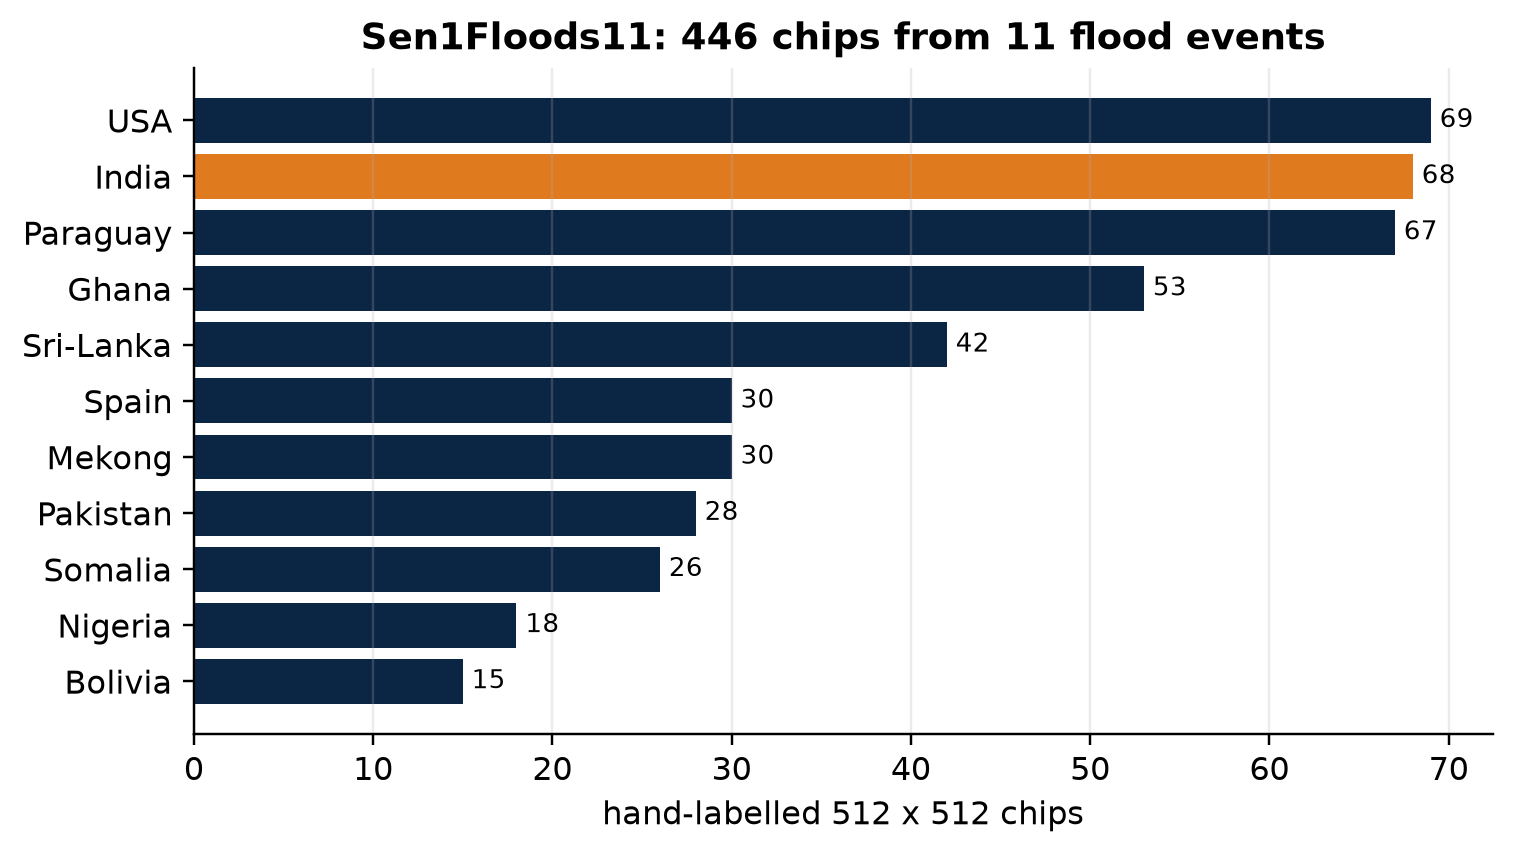

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_dataset_chips.png


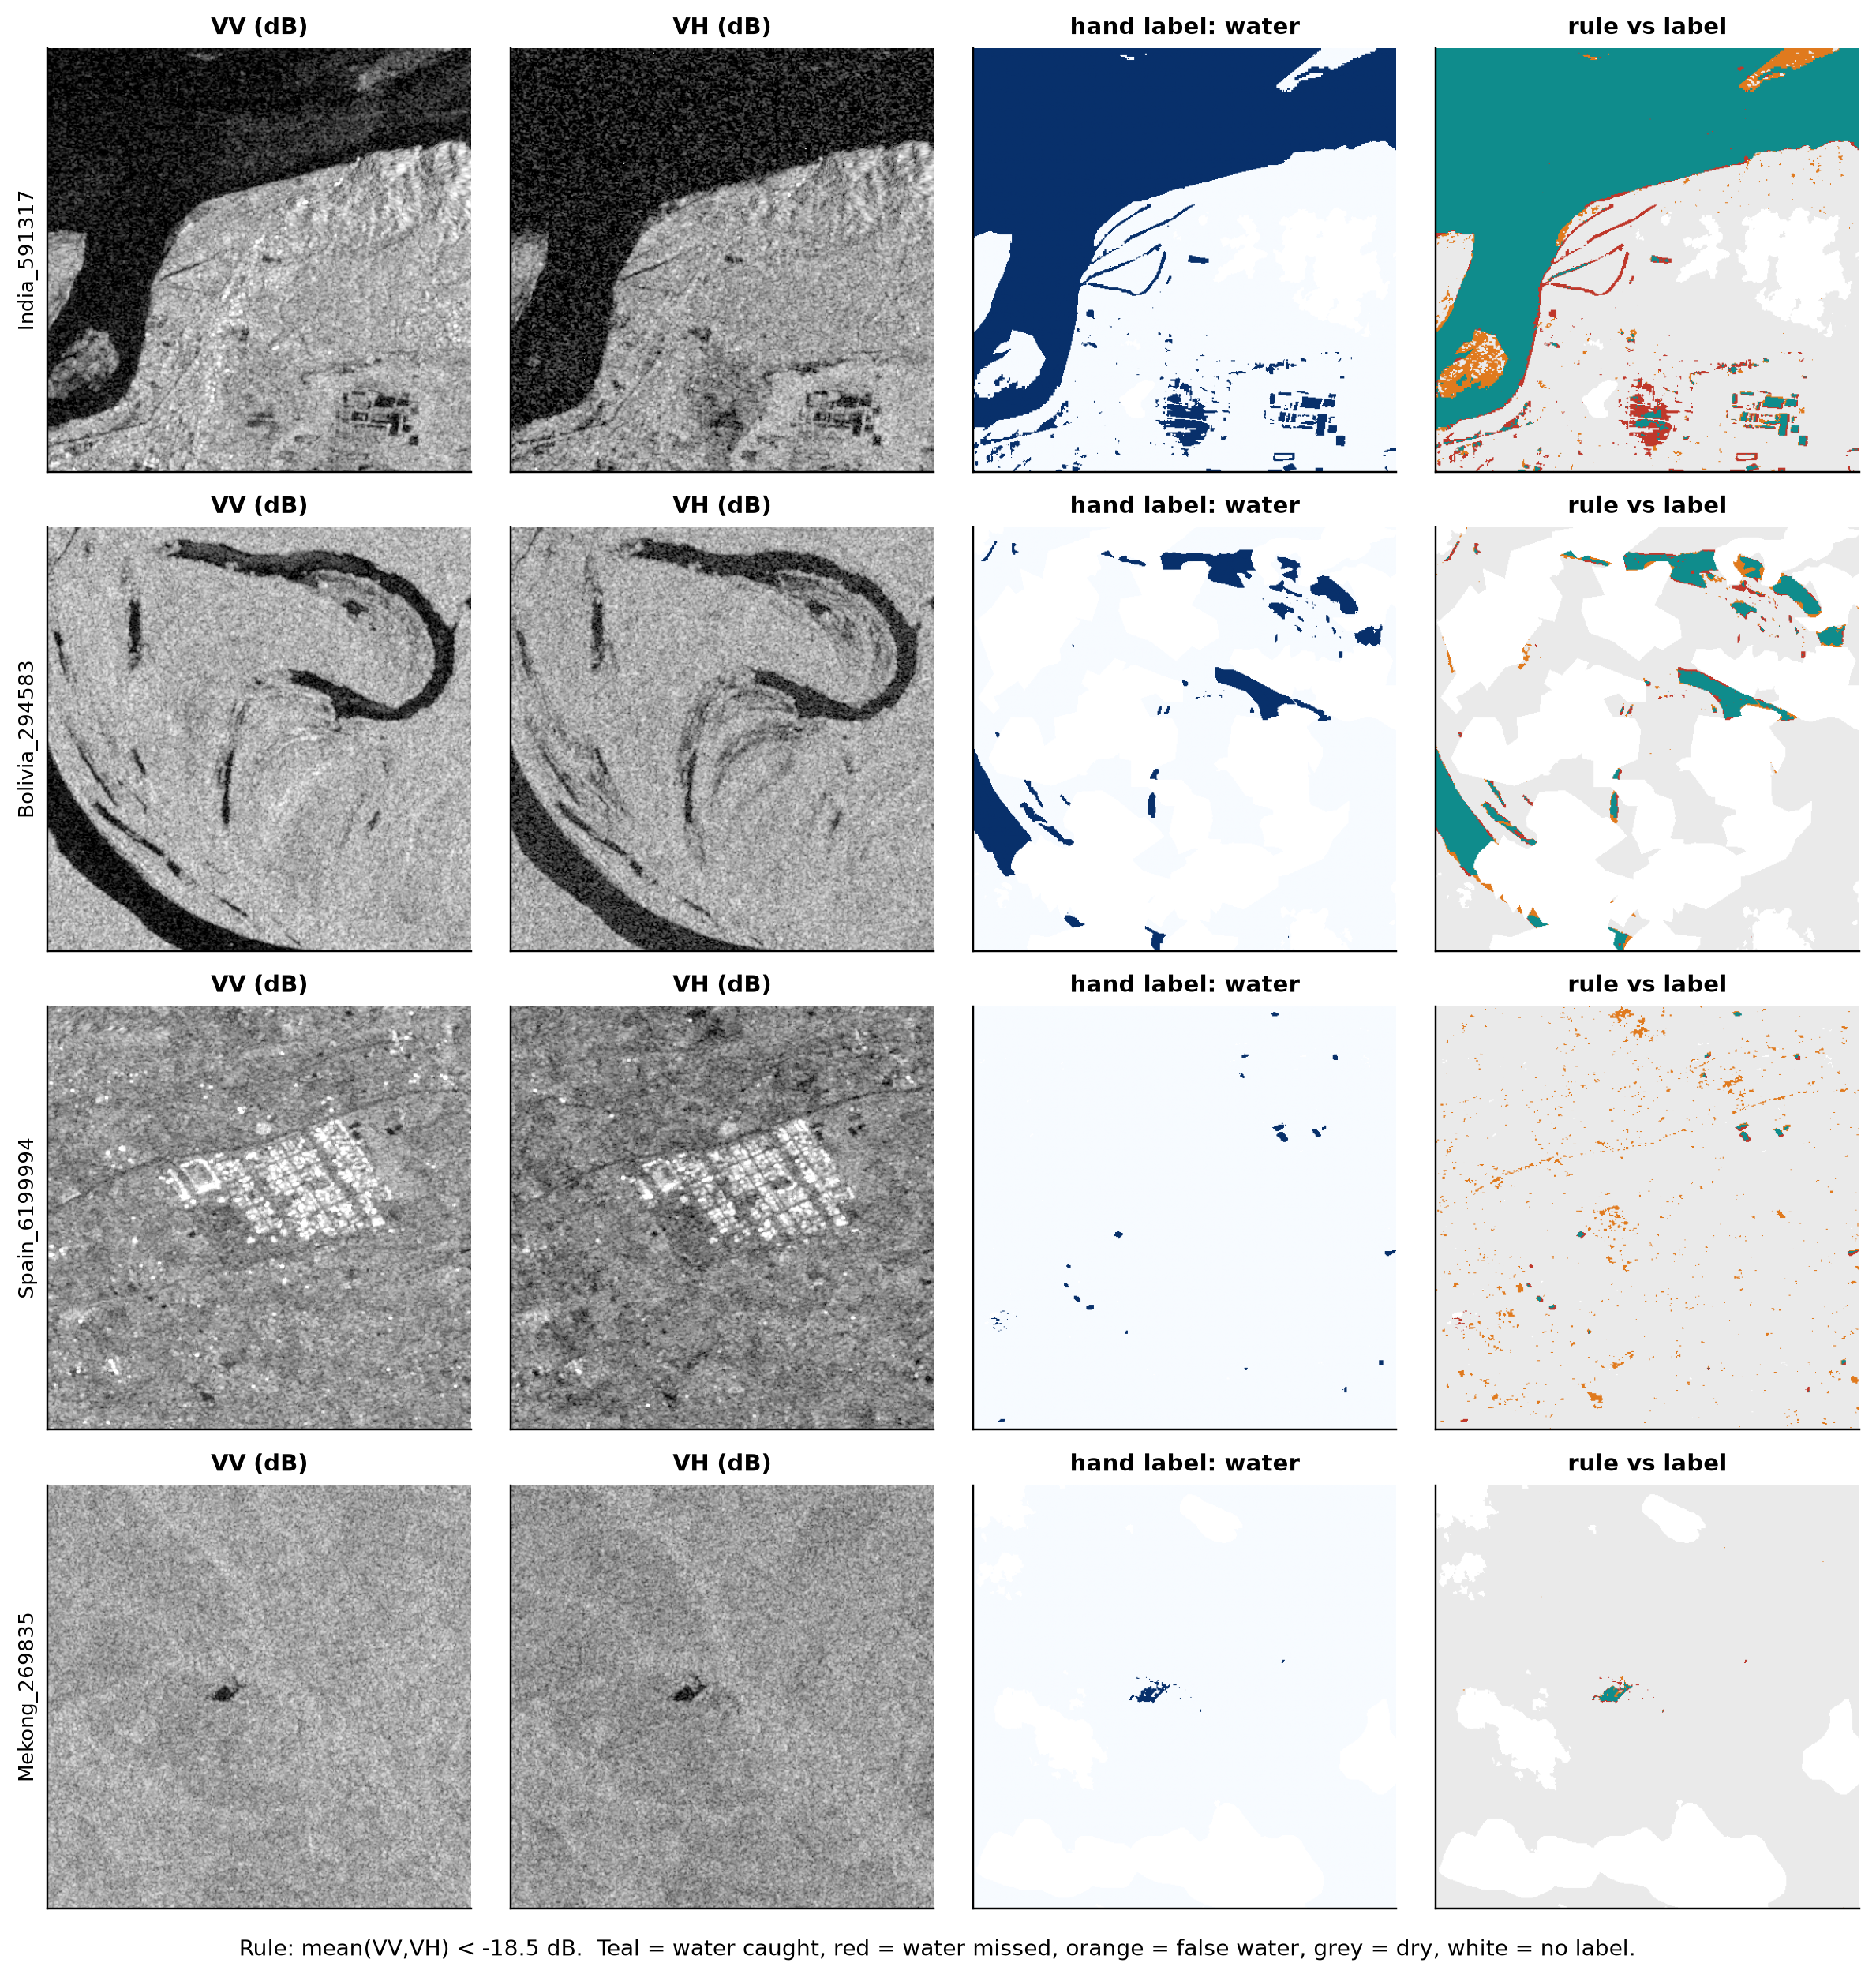

In [3]:
root = Path(LOCAL)
pairs = F.chip_pairs(root) if root.exists() else {}
if pairs:
    show(F.fig_dataset_overview(pairs))
    show(F.fig_dataset_chips(pairs, threshold_db=spa["step1_best_threshold_at_scale"]["200 m"]["db"] if spa else -18.5))
else:
    print(f"Sen1Floods11 not found at {LOCAL} - dataset figures skipped (set LOCAL above).")

## 2. Notebook 01 — one radar threshold, swept

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_01_threshold_sweep.png


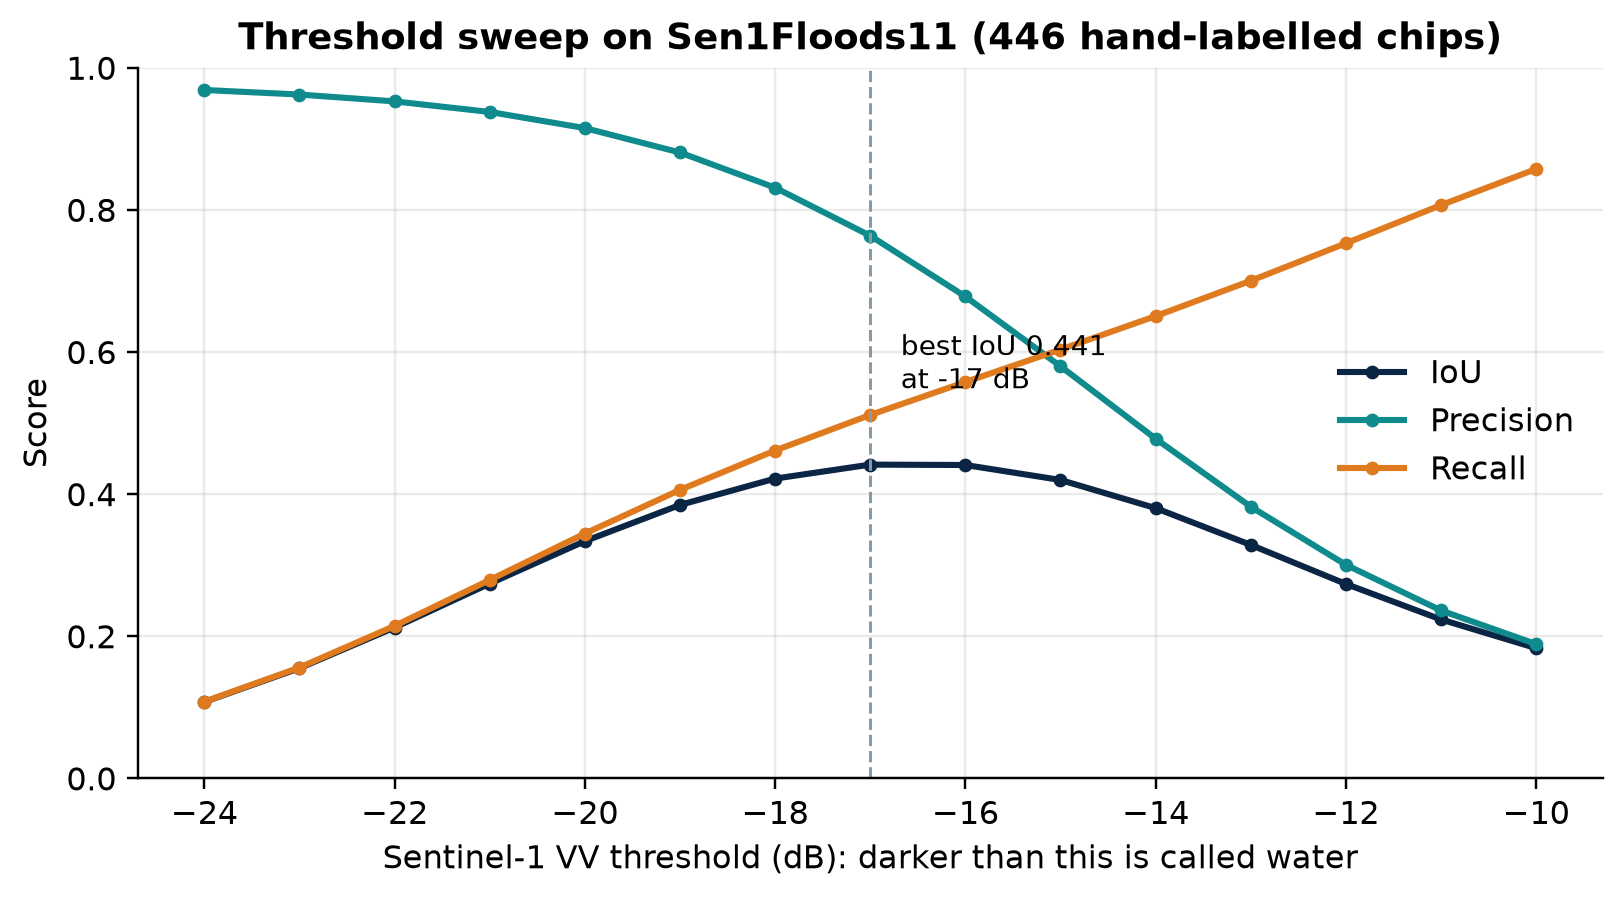

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_01_fixed_vs_otsu.png


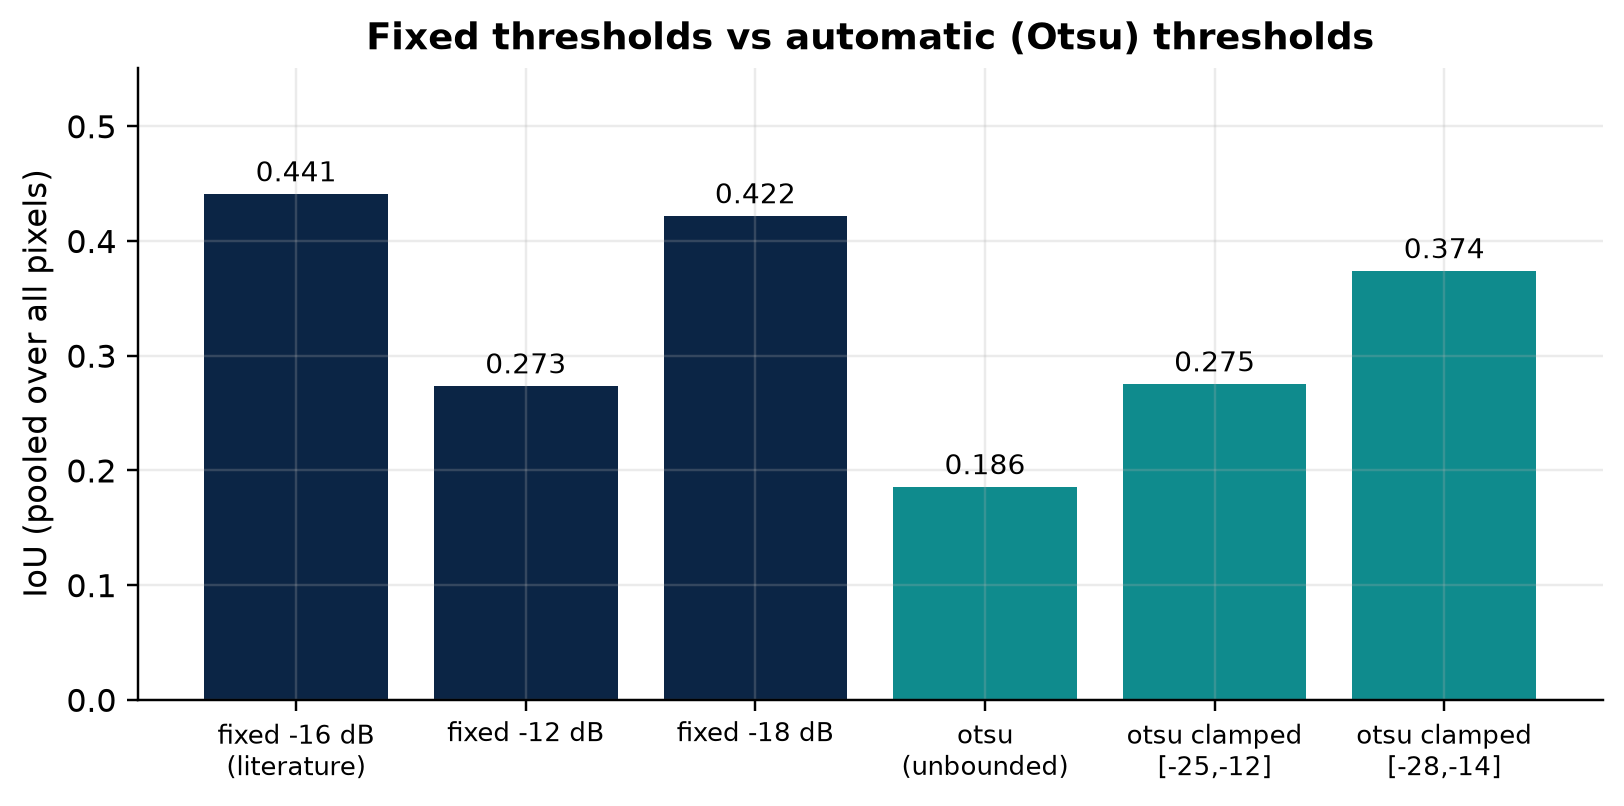

In [4]:
if s1f:
    show(F.fig_threshold_sweep(s1f))
    show(F.fig_otsu_methods(s1f))

## 3. Notebook 04 — VV, VH and where the missed water is

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_04_polarisation.png


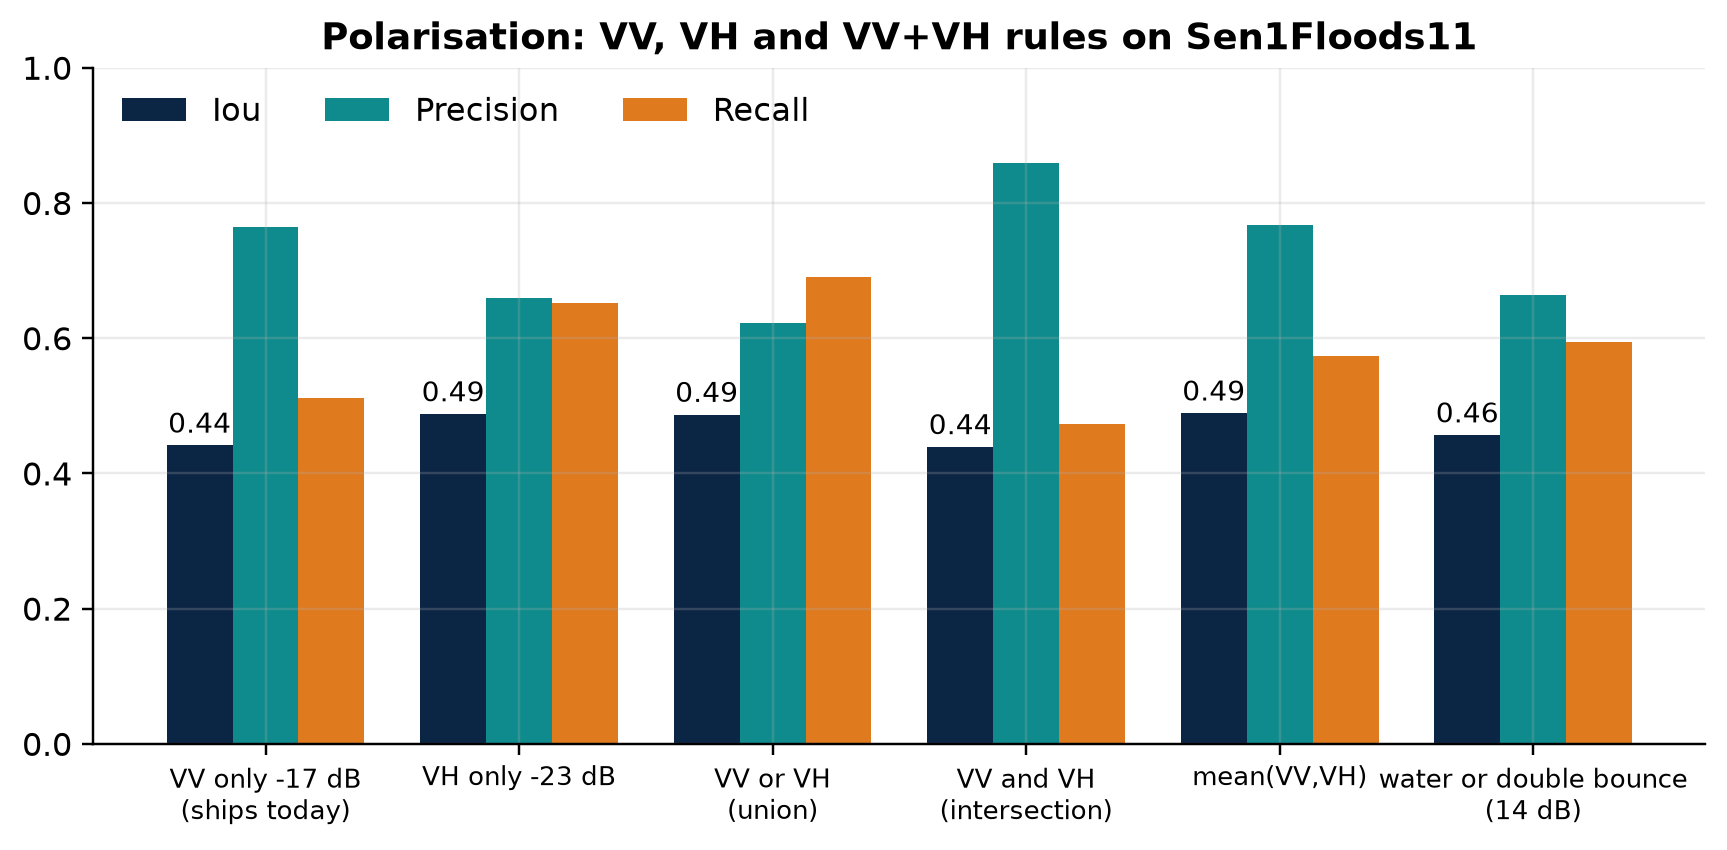

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_04_missed_water.png


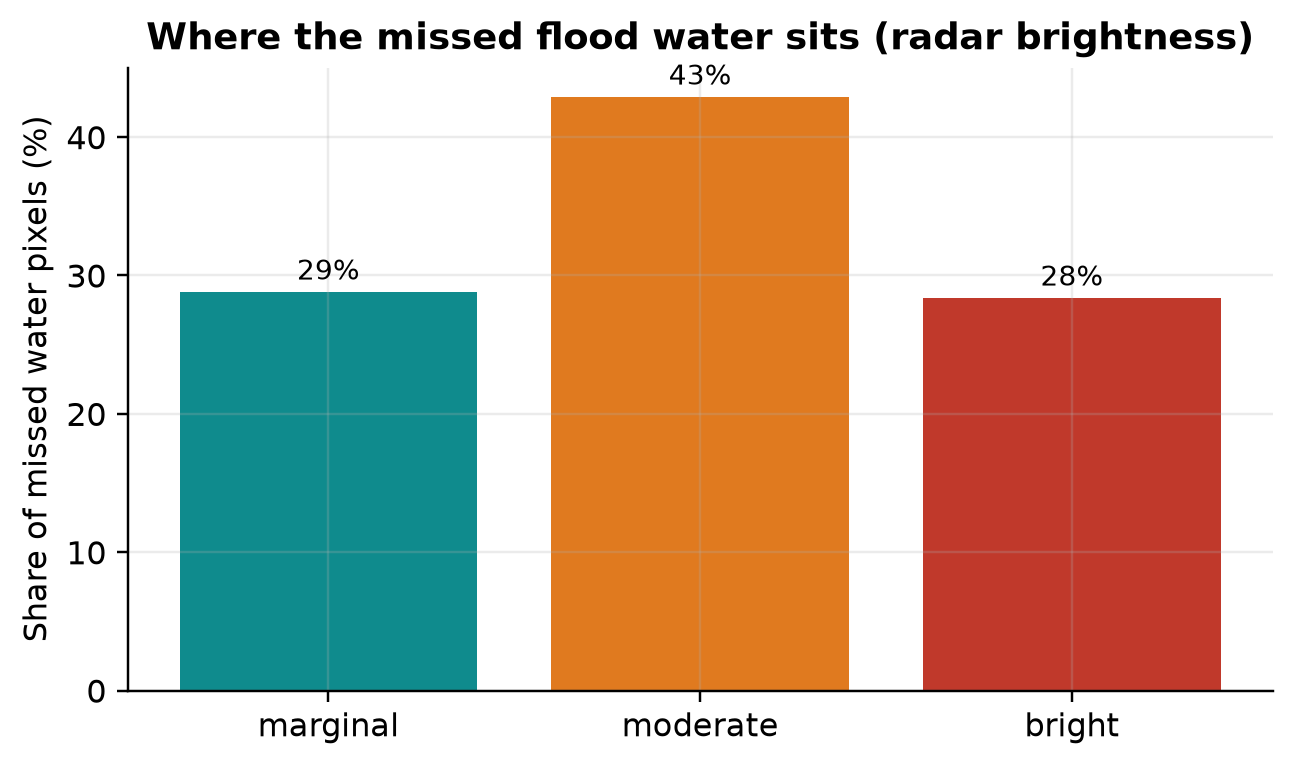

In [5]:
if pol:
    show(F.fig_polarisation(pol))
    show(F.fig_missed_water(pol))

## 4. Notebook 05 — optical (Sentinel-2) against radar

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_05_optical.png


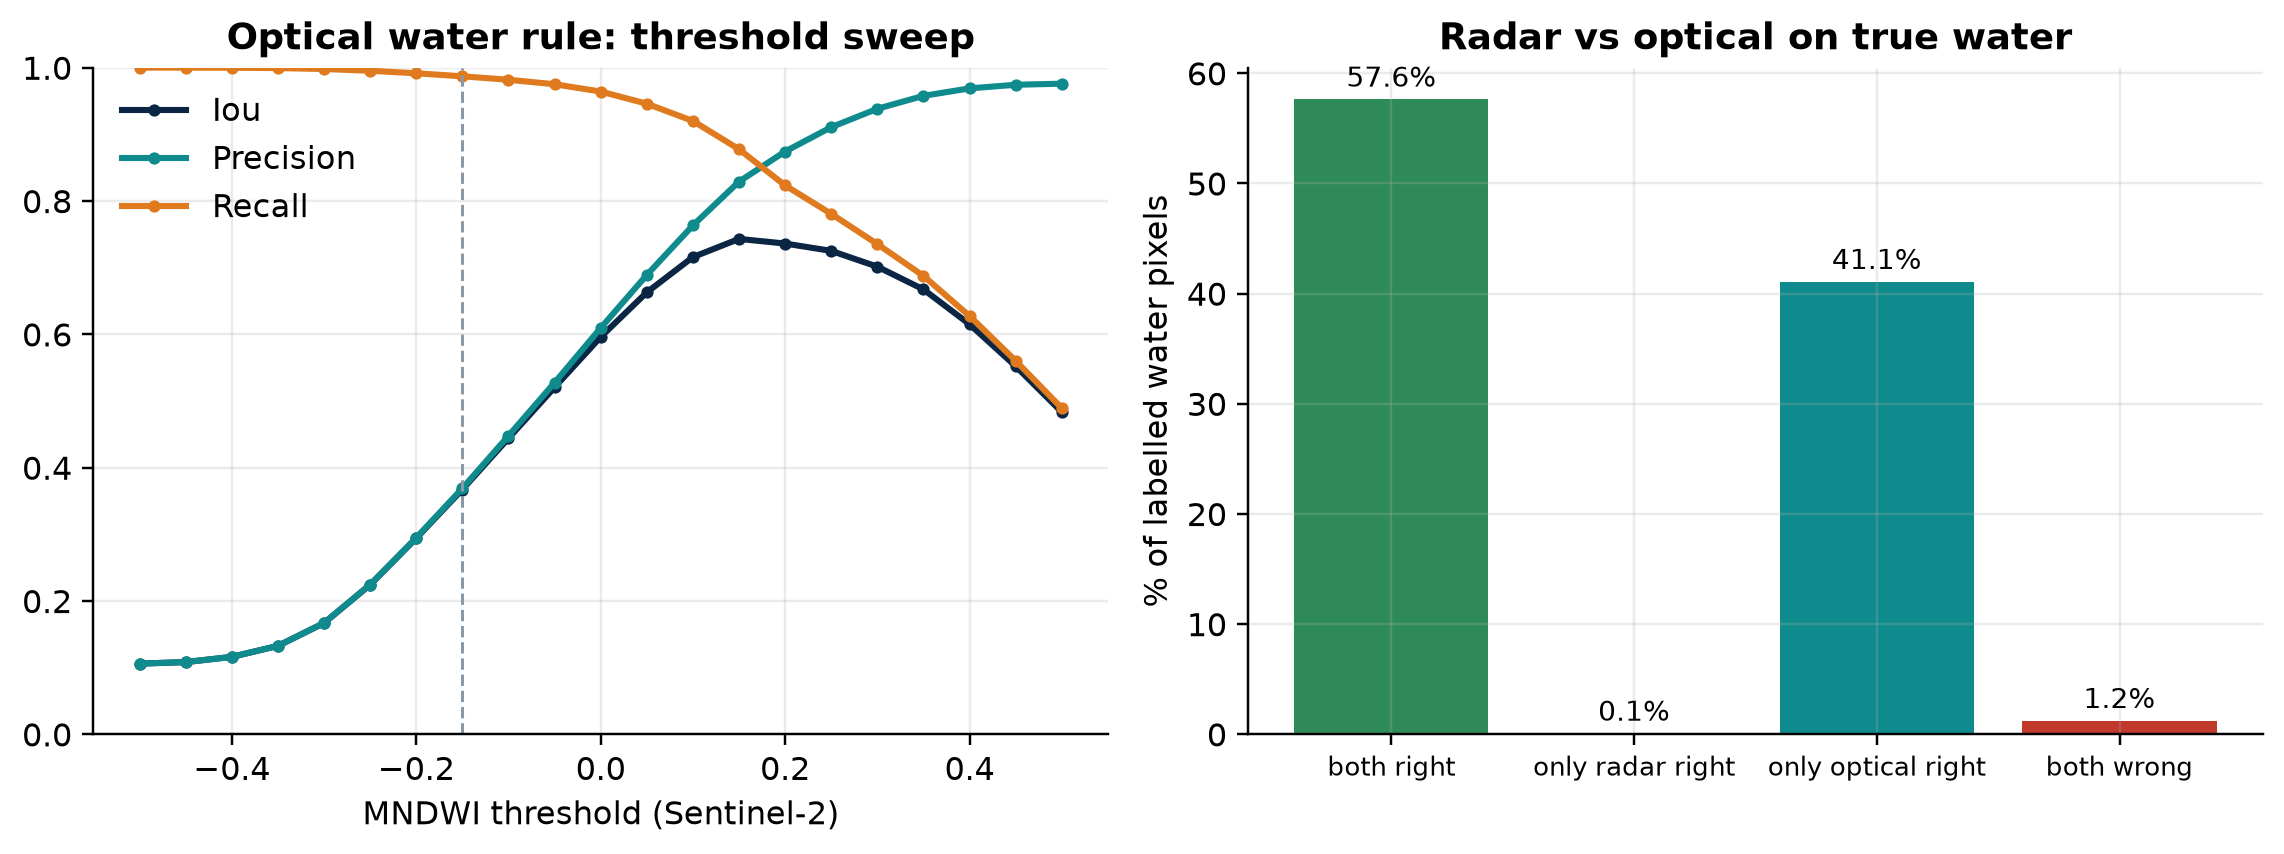

In [6]:
if opt:
    show(F.fig_optical(opt))

## 5. Notebook 06 — change detection

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_06_change_detection.png


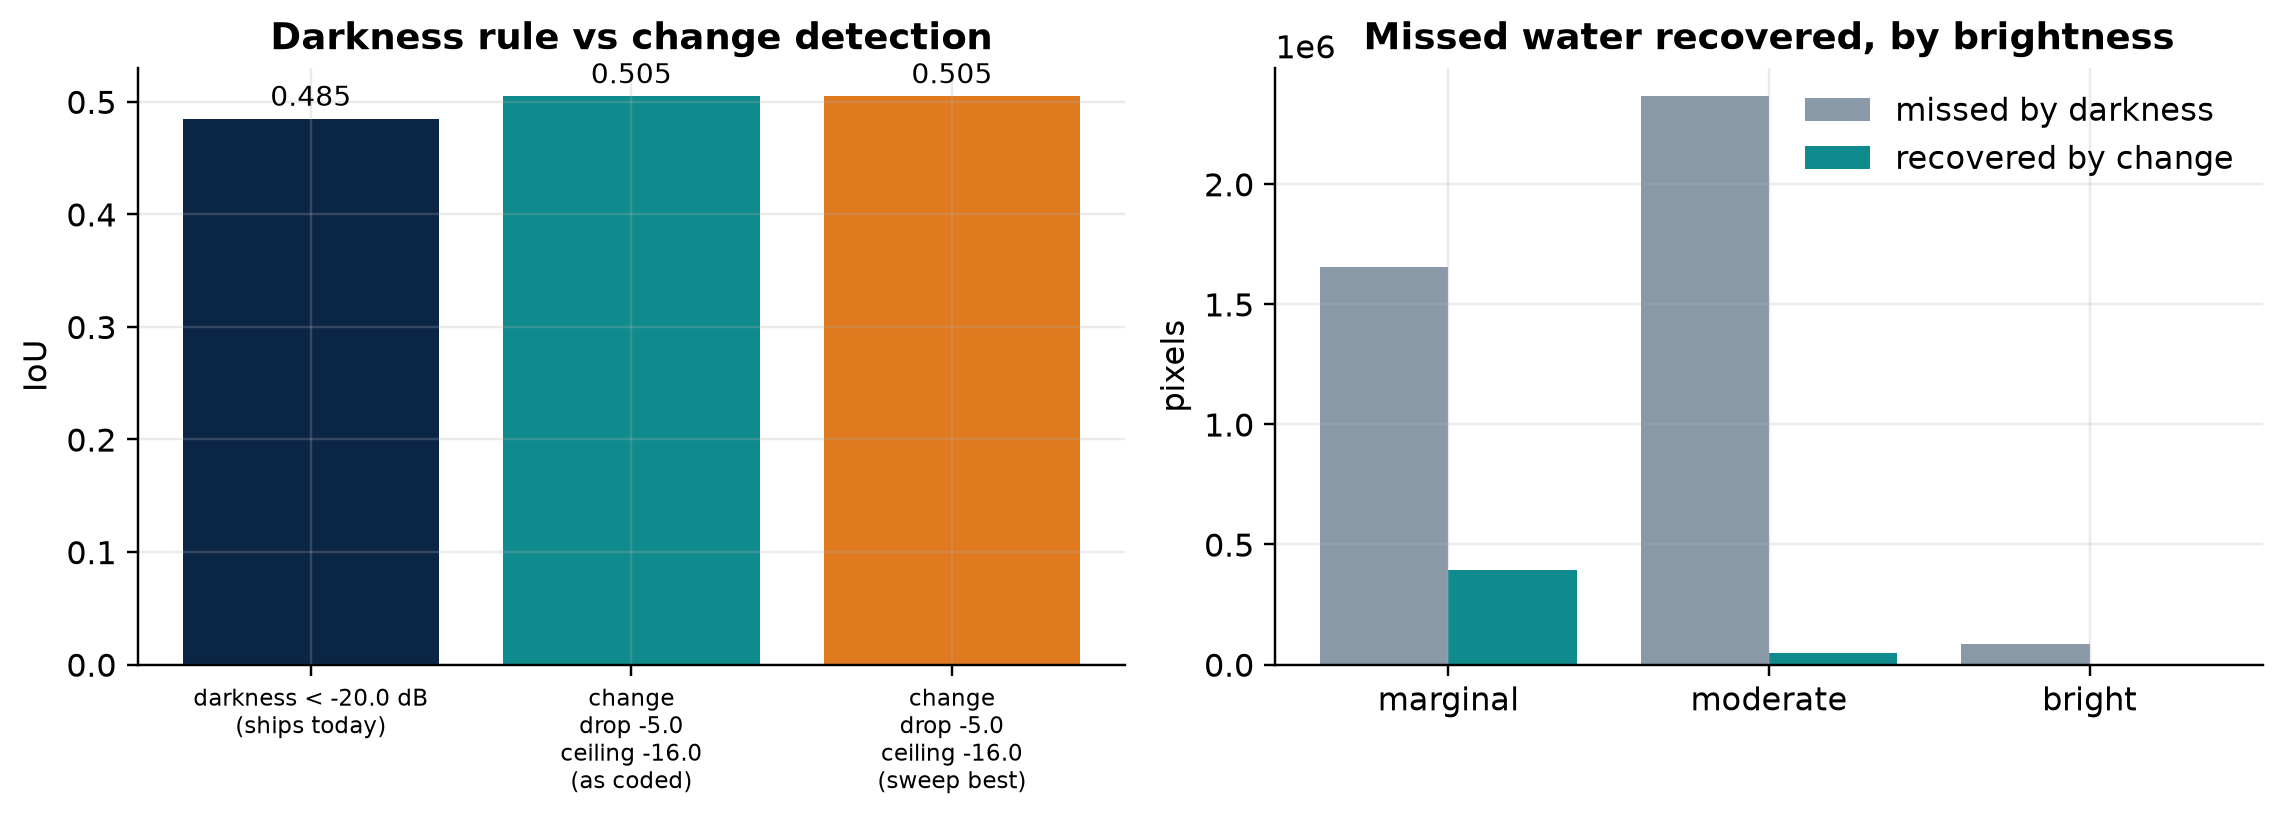

In [7]:
if chg:
    show(F.fig_change(chg))

## 6. Notebook 07 — analysis scale

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_07_scale.png


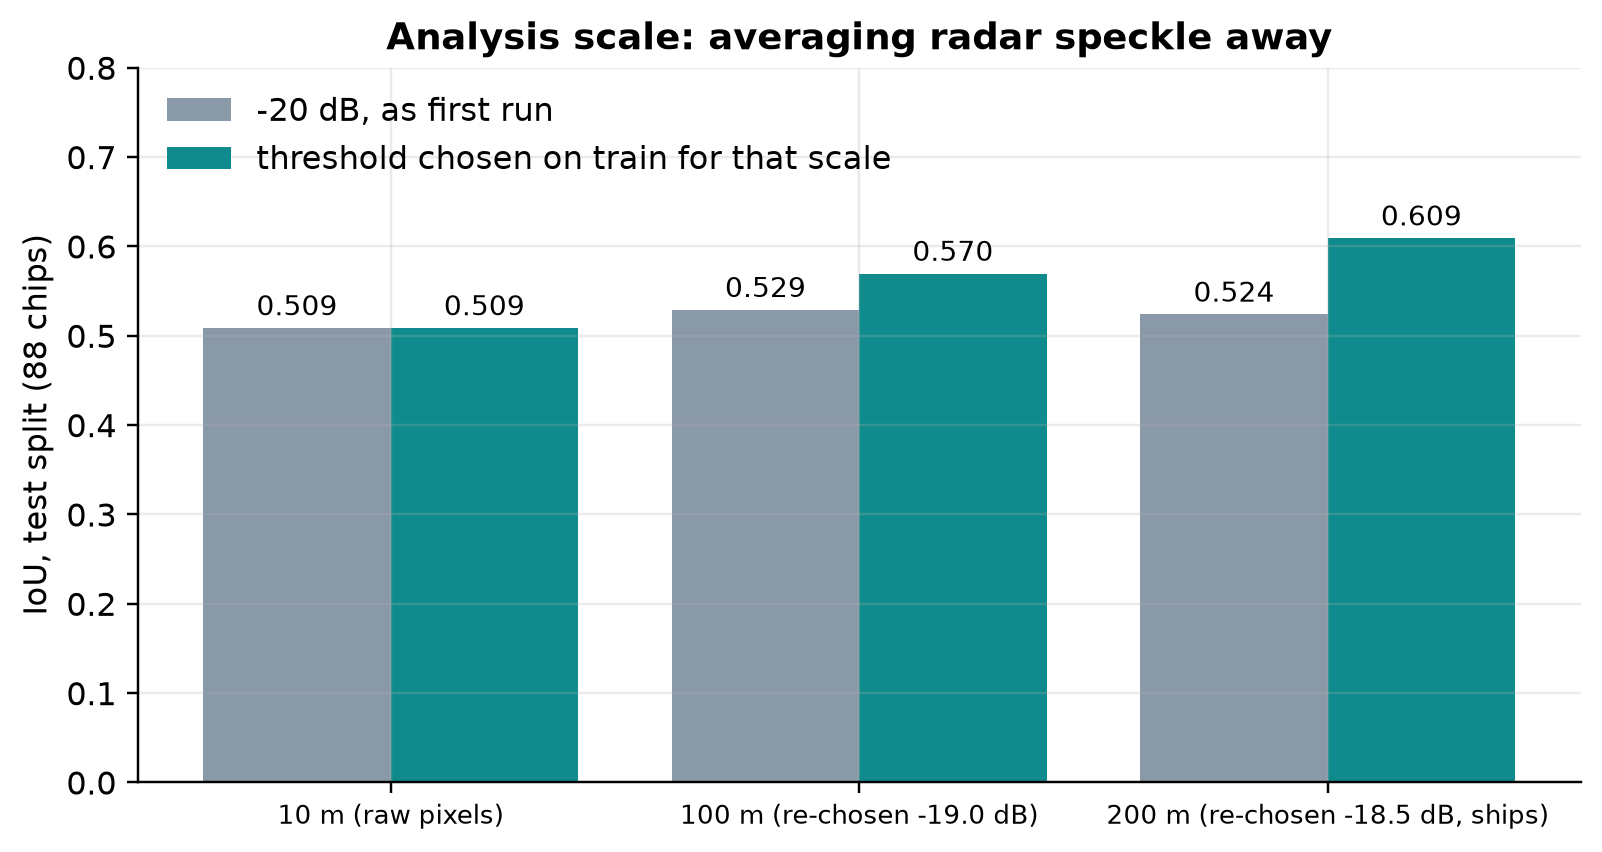

In [8]:
if spa:
    show(F.fig_scale(spa))

## 7. Notebook 08 — every flood event, and India

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_08_events_india.png


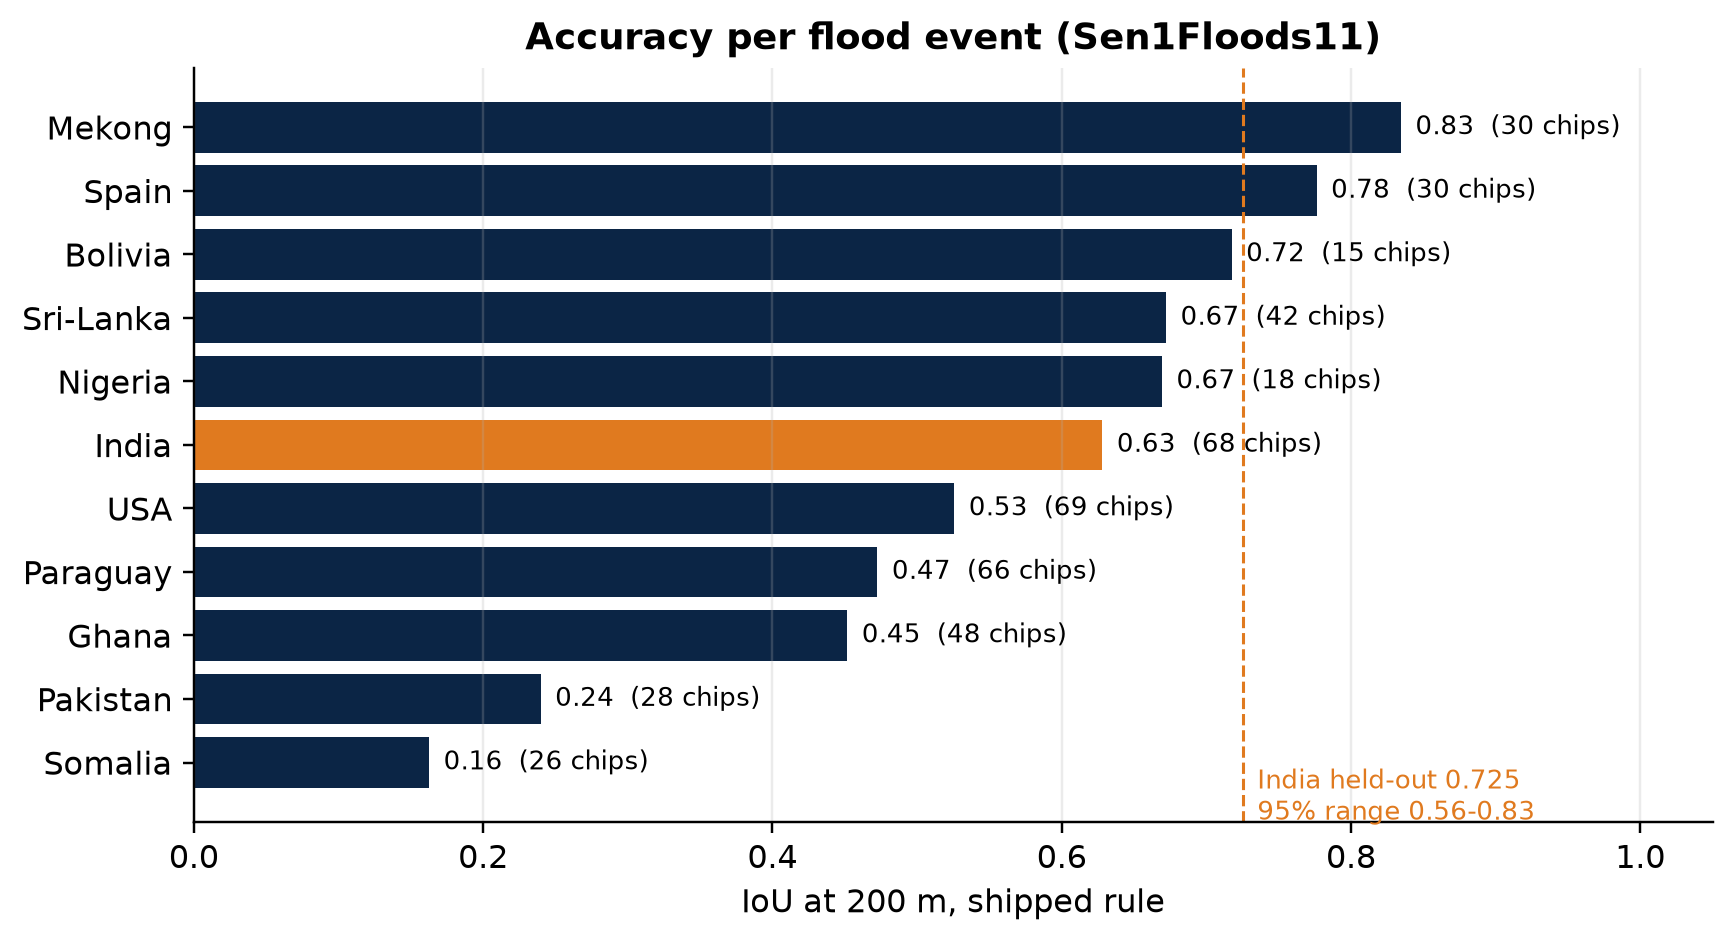

In [9]:
if evt:
    show(F.fig_events(evt))

## 8. Notebook 09 — the terrain check (measured, not shipped)

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_09_terrain.png


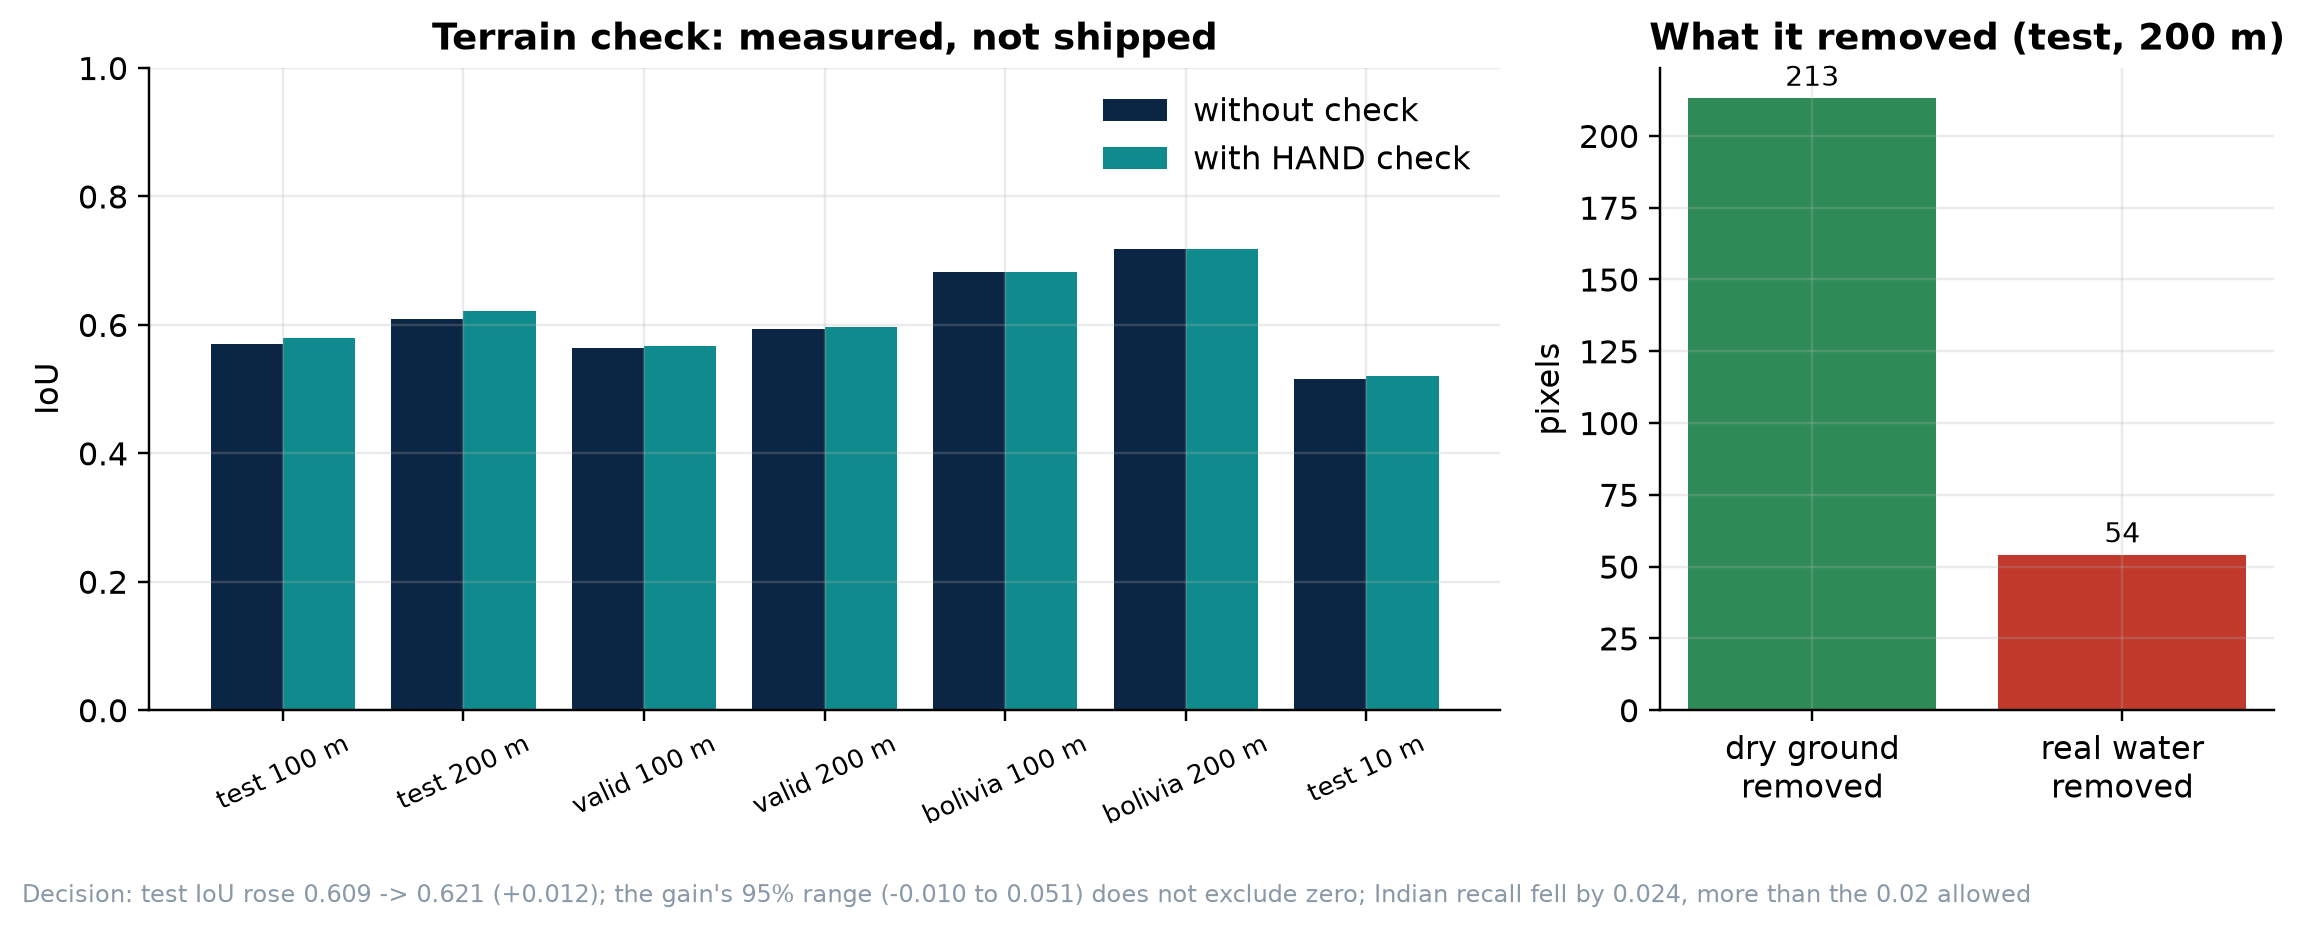

In [10]:
if ter:
    show(F.fig_terrain(ter))

## 9. Flood detection — the whole path in one chart

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_flood_methods_summary.png


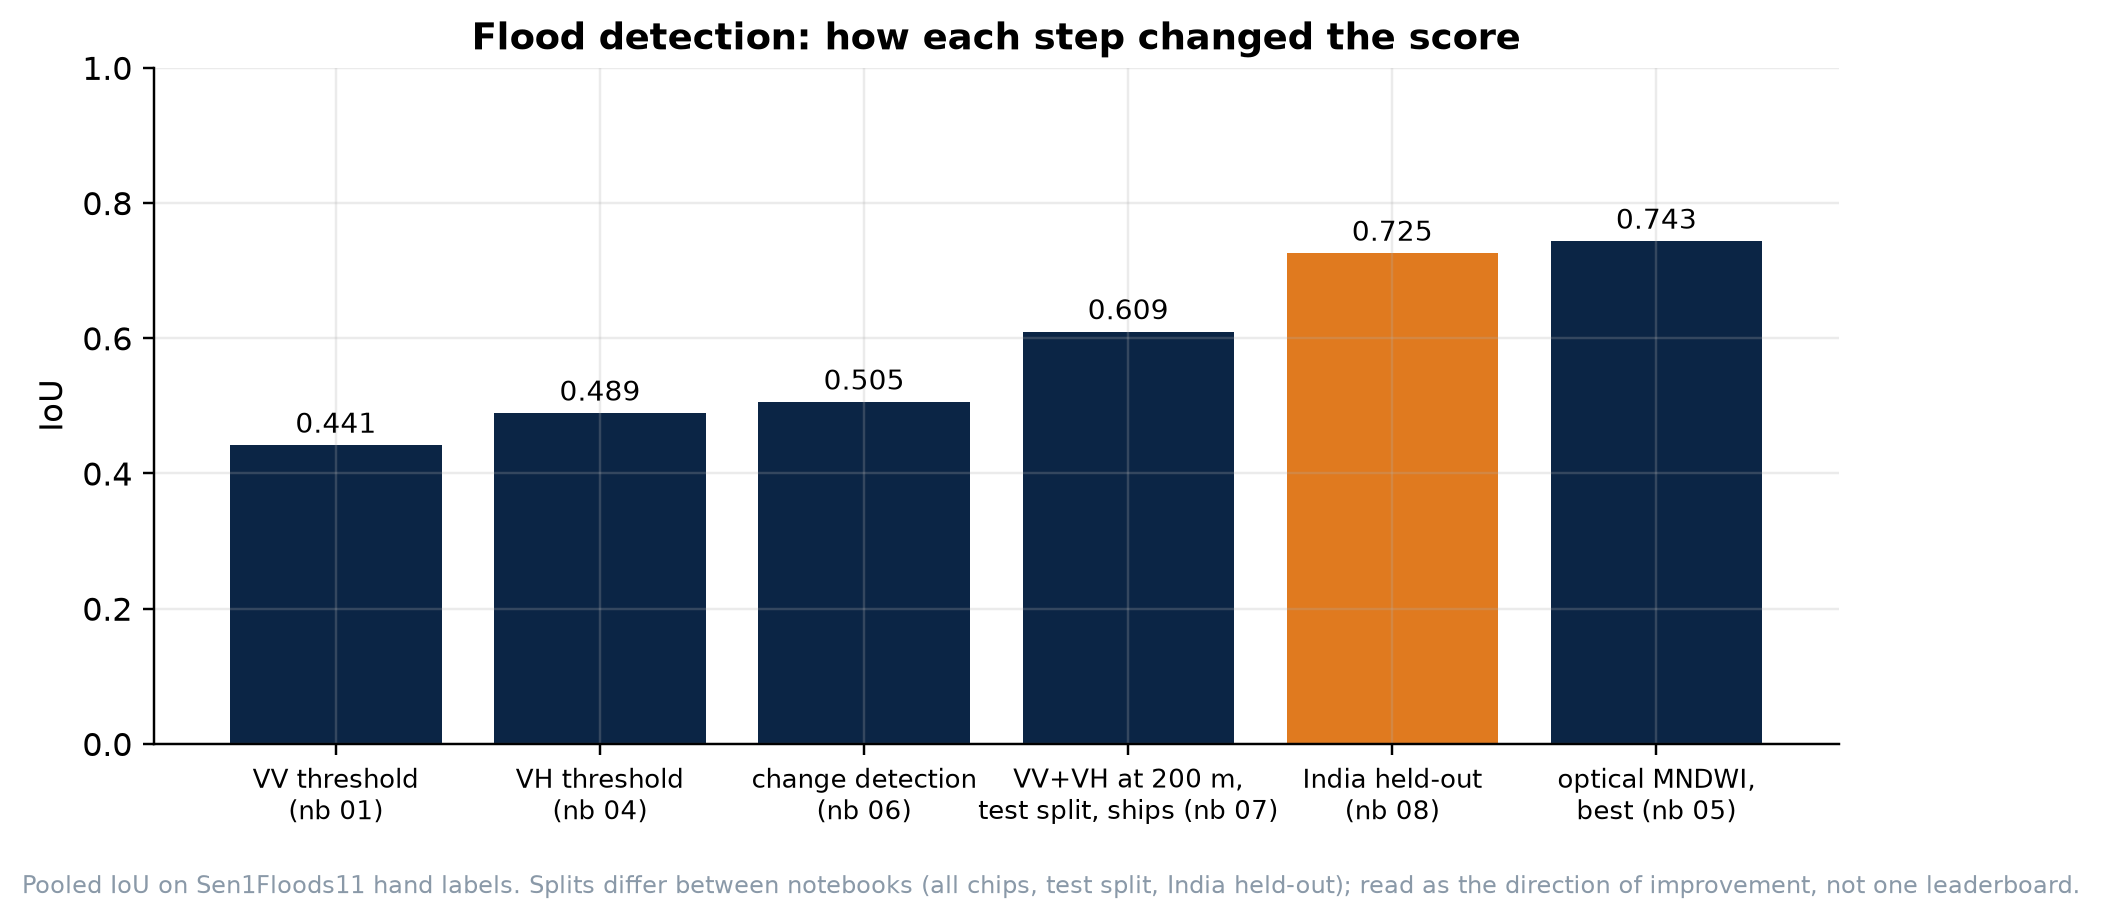

In [11]:
show(F.fig_flood_methods_summary(s1f, pol, spa, chg, opt, evt))

## 10. Surface analyses (against ESA WorldCover) and the Random Forest (notebook 02)

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_surface_accuracy.png


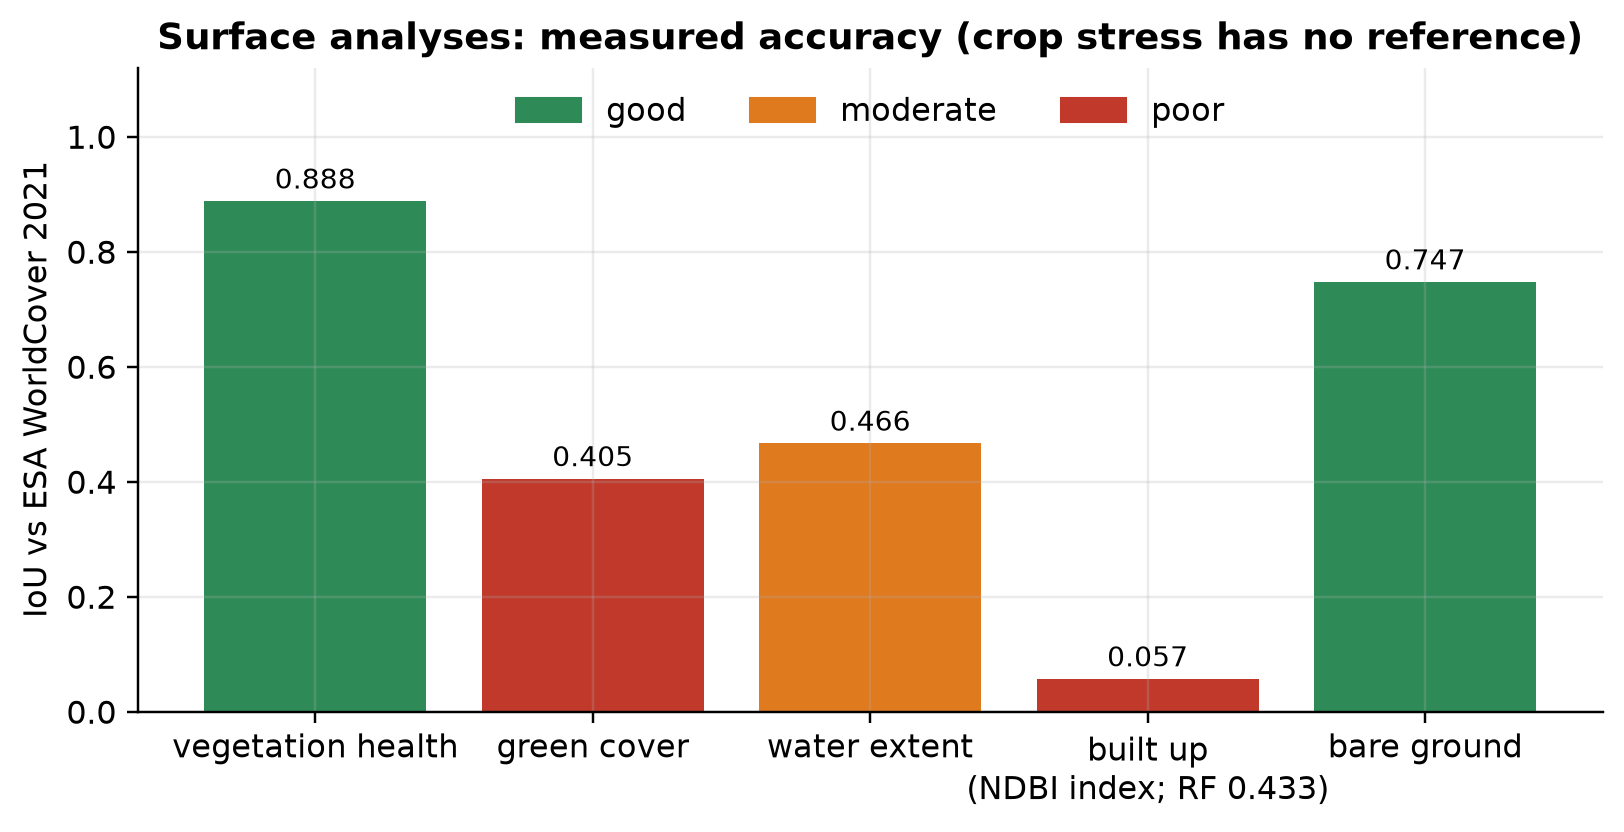

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_surface_districts.png


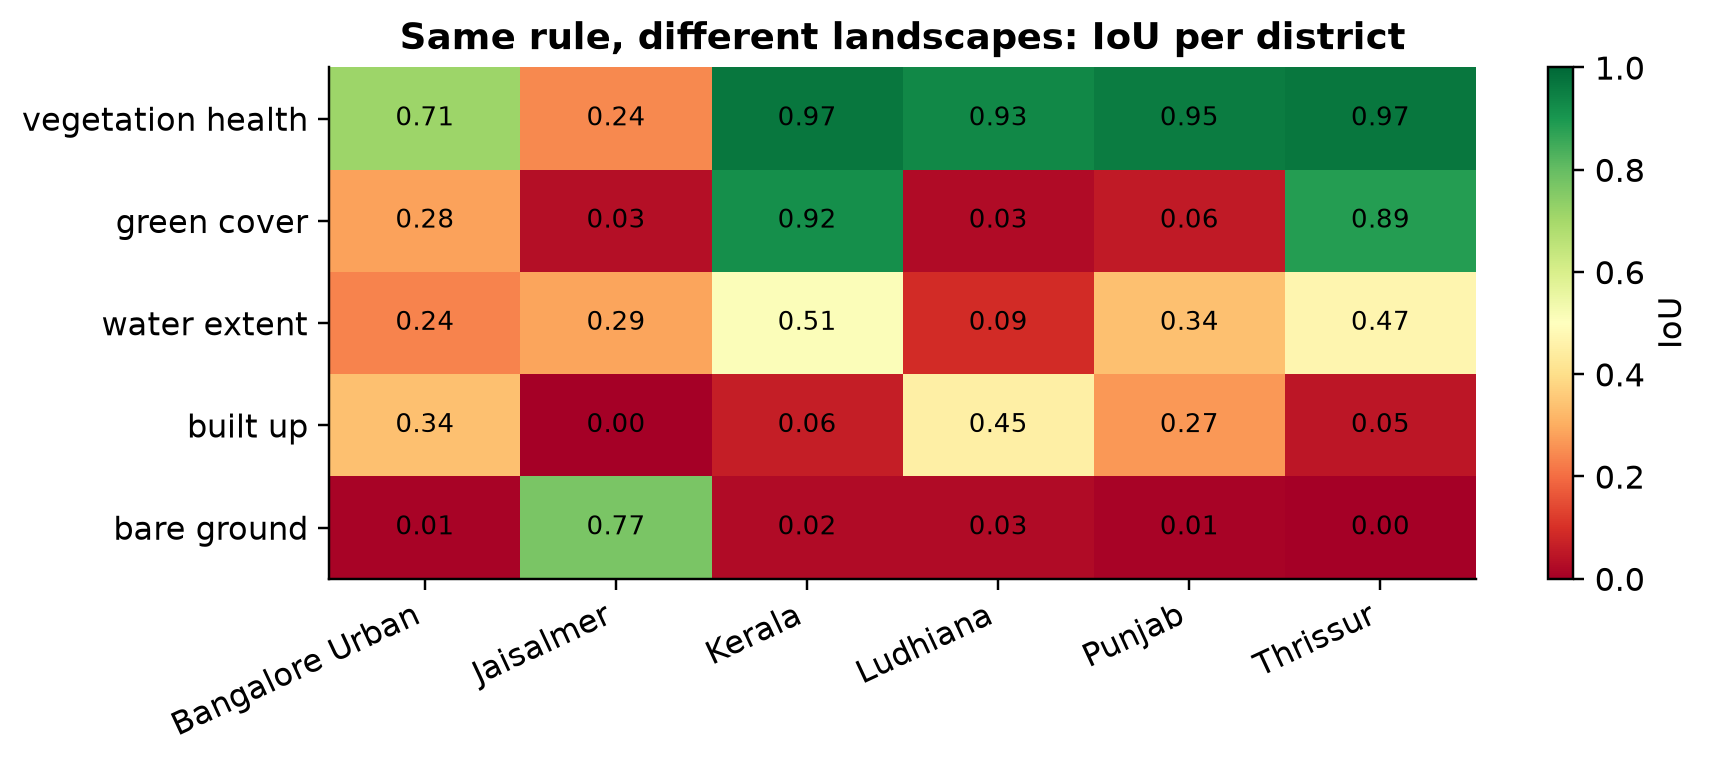

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_classifier_vs_index.png


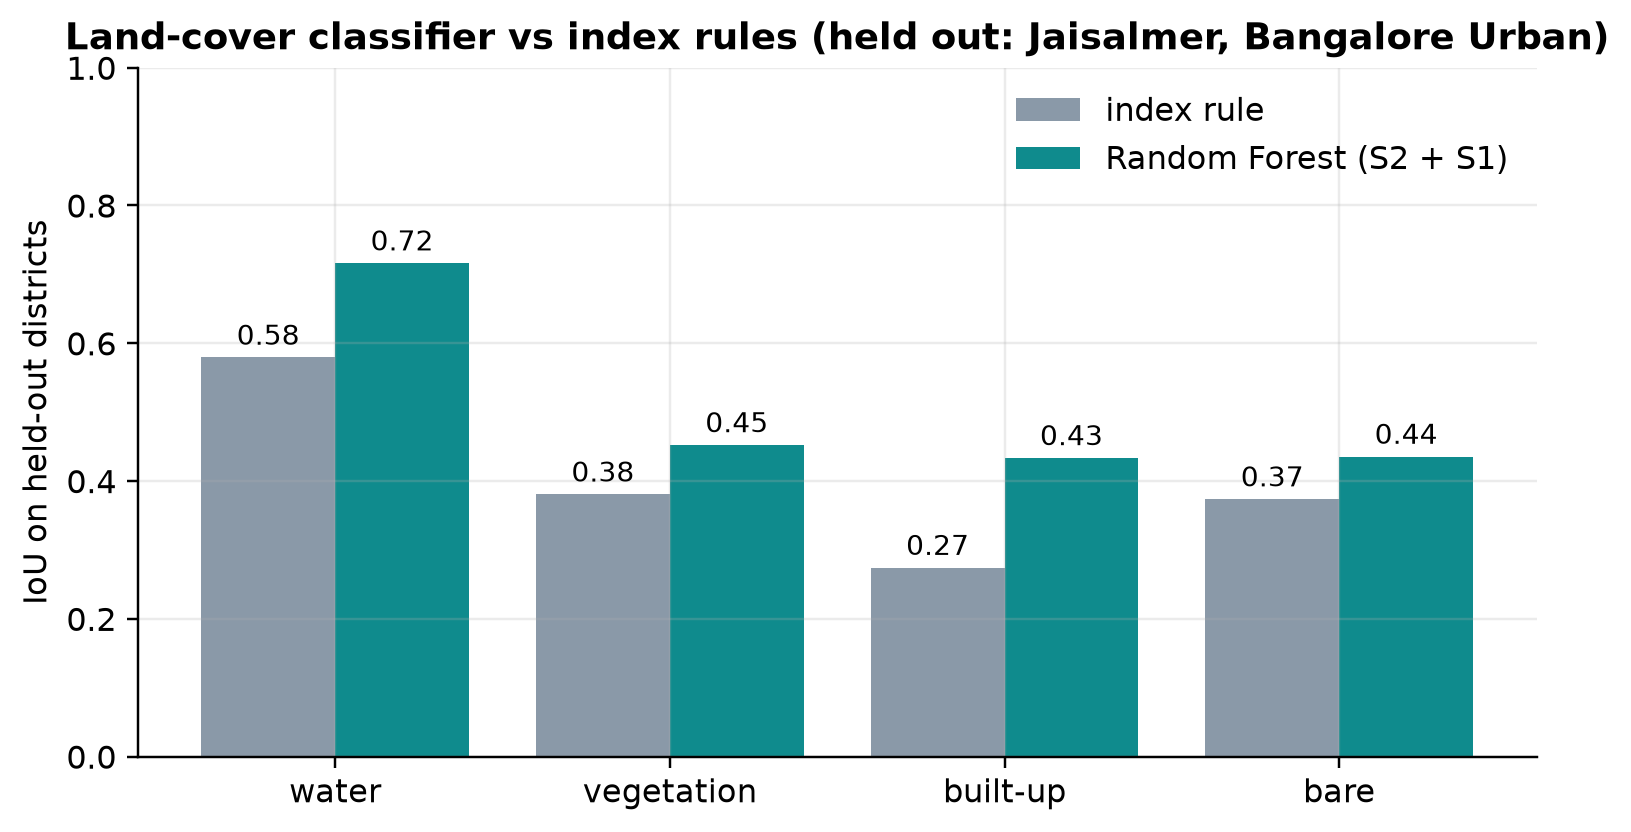

In [12]:
# Reliability as the app labels each analysis (detection/surface.py).
CLAIMS = {"vegetation_health": "good", "bare_ground": "good", "water_extent": "moderate",
          "green_cover": "poor", "built_up": "poor"}
if surf:
    show(F.fig_surface(surf, CLAIMS))
    show(F.fig_surface_districts(surf))
if model:
    show(F.fig_classifier(model))

## 11. Ask — how well questions are understood

saved C:\Users\punit\OneDrive\Desktop\Group_project\document\report_images\charts\fig_routing_accuracy.png


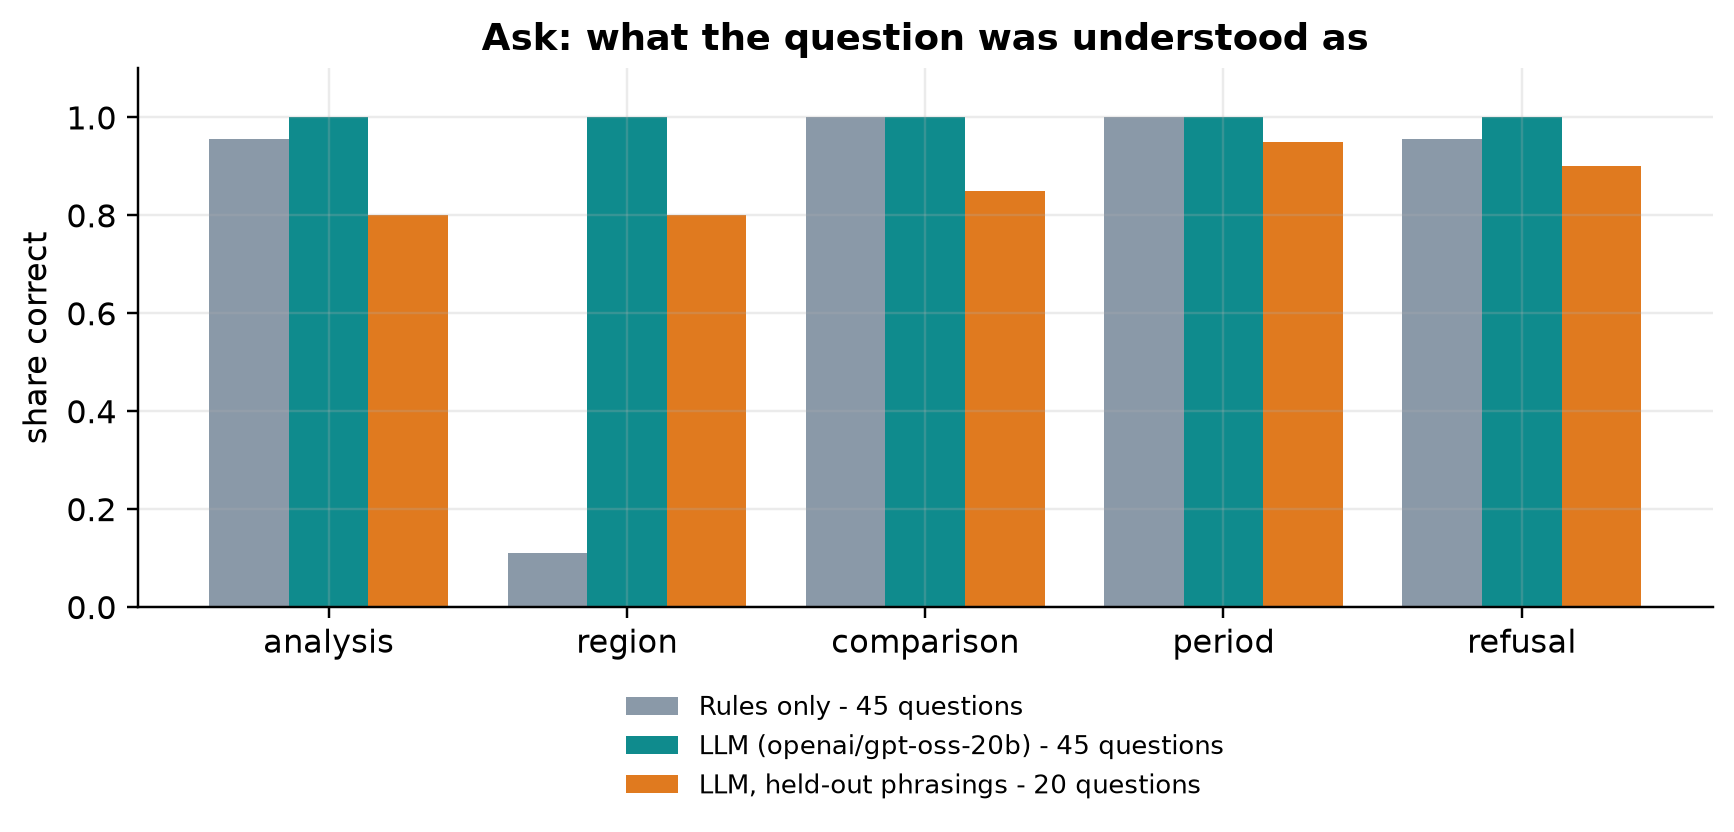

In [13]:
if llm:
    show(F.fig_routing(llm, rules, held))

## Done

All figures are in `document/report_images/charts/`. File names start with the notebook
they come from (`fig_07_scale.png` is notebook 07), so each can be cited next to its
measurement in Chapter 4.